# 11-Data Contracts & Schema Registries

In Lesson 09, we built a Distributed Event Streaming Fabric (Apache Kafka), and in Lesson 10, we built a Data Lakehouse (Iceberg/Delta). We have successfully decoupled storage from compute and decoupled data producers from data consumers.

However, this infinite decoupling introduces the most fatal vulnerability in modern Data Engineering: **Schema Drift (The Silent Poison)**.
Because the Software Engineering team (Producers) and the Data Engineering team (Consumers) operate independently, the Software Engineers might deploy an application update that changes a database column `user_id` from an `INTEGER` to a `STRING` (UUID), or they might drop a `revenue` column entirely.

Because Kafka and Object Storage blindly accept raw byte arrays, the upstream application will continuously pump this new, incompatible data into the Kafka topic. The pipeline will physically succeed, but when the downstream Airflow/dbt jobs attempt to sum the `revenue` column, they will violently crash, destroying executive dashboards.

To bridge this gap, we must formalize an explicit API between producers and consumers. We must engineer **Data Contracts** and enforce them using a **Schema Registry**.

Let's set up our environment to engineer strict serialization boundaries.

In [1]:
# Required installations: pip install fastavro matplotlib seaborn pandas
import io
import json
import fastavro
from fastavro.validation import validate
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Schema Enforcement Environment Initialized.")

✅ Systems Architecture & Schema Enforcement Environment Initialized.


# 1. The Mathematics of Schema Evolution

A Data Contract is not a Wiki page or a Slack message; it is a mathematically enforced, machine-readable document (typically written in **Apache Avro** or **Protobuf**).

Let an Event Payload $E$ be a dictionary of keys and values.
Let a Schema $\mathcal{S}$ be a strict topological map defining exactly which keys must exist and their immutable memory types (e.g., 32-bit Integer, String).

Before an Event can physically enter the Kafka network, it must pass through the **Serialization Function** $\sigma$. The function attempts to map $E$ into a raw binary byte array $B$, strictly guided by $\mathcal{S}$:


$$\sigma(E, \mathcal{S}) \rightarrow \begin{cases} 
B \in \{0, 1\}^* & \text{if } E \text{ strictly conforms to } \mathcal{S} \\
\text{Halt \& Throw Exception} & \text{if } E \notin \mathcal{S} 
\end{cases}$$

### The Schema Registry Matrix

A Schema Registry is an independent REST server that acts as the Supreme Court of data structures. It stores every historical version of a schema ($\mathcal{S}_{v1}, \mathcal{S}_{v2}, \dots$).
When a software engineer attempts to register $\mathcal{S}_{v2}$, the Registry executes a mathematical **Compatibility Matrix Check**:

1. **Backward Compatibility**: Can the existing Data Warehouse consumers (using $\mathcal{S}_{v1}$) still read the new data produced by $\mathcal{S}_{v2}$? (e.g., Adding a *new optional* column is safe. Deleting a *required* column is a fatal violation).
2. **Forward Compatibility**: Can a new consumer (using $\mathcal{S}_{v2}$) read old data produced by $\mathcal{S}_{v1}$?

If the compatibility function evaluates to $False$, the Schema Registry violently rejects the software engineer's CI/CD pipeline, physically preventing them from deploying the schema-breaking code to production.

# 2. Architecting the Strict Avro Data Contract

Let's build a real, executable Schema Enforcement engine using Apache Avro.
We will:

1. Define a strict JSON-based Avro Data Contract.
2. Compile the schema into memory.
3. Test a valid transaction payload, successfully serializing it into highly compressed binary.
4. Test a corrupted payload containing a schema drift violation, watching the physical gatekeeper reject the data before it can ever touch a Kafka stream.

In [2]:
# --- 📜 STEP 1: Defining the Data Contract (The API Agreement) ---
print("--- 📐 Defining Apache Avro Data Contract ---")

# The Contract: A strict definition agreed upon by SWEs and Data Engineers
# Avro schemas are heavily structured JSON payloads.
transaction_schema = {
    "namespace": "enterprise.finance",
    "type": "record",
    "name": "TransactionEvent",
    "doc": "Data Contract for all corporate revenue events.",
    "fields": [
        {"name": "transaction_id", "type": "string"},
        {"name": "user_id", "type": "int", "doc": "Must be a strict 32-bit integer."},
        {"name": "amount_usd", "type": "float"},
        # A 'union' with null means this column is explicitly OPTIONAL
        {"name": "discount_code", "type": ["null", "string"], "default": None}
    ]
}

# Compile the schema into the Avro C-engine
parsed_schema = fastavro.parse_schema(transaction_schema)
print("✅ Data Contract v1.0 securely compiled into validation engine.")


# --- 🟢 STEP 2: The Serialization Physics (Valid Payload) ---
print("\n--- 🟢 Simulating Valid Production Event ---")

valid_event = {
    "transaction_id": "TXN-9942A",
    "user_id": 1054,
    "amount_usd": 149.99,
    "discount_code": "SUMMER26"
}

# 1. Validate the payload against the strict topological map
validate(valid_event, parsed_schema)

# 2. Serialize the dictionary into raw binary (Simulating the Kafka Producer Network Write)
binary_buffer = io.BytesIO()
fastavro.writer(binary_buffer, parsed_schema, [valid_event])

binary_payload = binary_buffer.getvalue()
print(f"   ✅ Event successfully verified and serialized into {len(binary_payload)} bytes of raw binary.")
print(f"   [Binary Hex Dump]: {binary_payload.hex()[:50]}...")


# --- 🛑 STEP 3: The Interception Physics (Schema Drift / Corrupted Payload) ---
print("\n--- 🛑 Simulating Schema Drift (Upstream Engineering Error) ---")

# The Software Engineer changes user_id to a UUID string and drops 'amount_usd'
corrupted_event = {
    "transaction_id": "TXN-9943B",
    "user_id": "c8a4f-991b", # FATAL: String passed to Integer field
    # FATAL: amount_usd is completely missing
    "discount_code": None
}

print(f"   Incoming Payload: {json.dumps(corrupted_event)}")

try:
    # The mathematical gatekeeper steps in
    validate(corrupted_event, parsed_schema)
    
except Exception as e:
    print(f"\n   ❌ [SCHEMA REGISTRY GATEKEEPER TRIGGERED]")
    print(f"   FATAL VIOLATION: {str(e)}")
    print("   -> The event has been blocked. The Kafka producer throws an exception.")
    print("   -> Downstream Data Warehouse integrity preserved.")

print("\n--- 💡 Engineering Insight ---")
print("Notice how the validation engine caught the error locally in the producer's memory. The corrupted data never hit the network. By forcing all producers to download the schema from the Schema Registry and serialize against it, you mathematically guarantee that your Kafka topics contain 100% cleanly typed, structurally perfect data. There is no 'garbage in'.")

--- 📐 Defining Apache Avro Data Contract ---
✅ Data Contract v1.0 securely compiled into validation engine.

--- 🟢 Simulating Valid Production Event ---
   ✅ Event successfully verified and serialized into 469 bytes of raw binary.
   [Binary Hex Dump]: 4f626a0104146176726f2e636f646563086e756c6c16617672...

--- 🛑 Simulating Schema Drift (Upstream Engineering Error) ---
   Incoming Payload: {"transaction_id": "TXN-9943B", "user_id": "c8a4f-991b", "discount_code": null}

   ❌ [SCHEMA REGISTRY GATEKEEPER TRIGGERED]
   FATAL VIOLATION: [
  "enterprise.finance.TransactionEvent.user_id is <c8a4f-991b> of type <class 'str'> expected int"
]
   -> The event has been blocked. The Kafka producer throws an exception.
   -> Downstream Data Warehouse integrity preserved.

--- 💡 Engineering Insight ---
Notice how the validation engine caught the error locally in the producer's memory. The corrupted data never hit the network. By forcing all producers to download the schema from the Schema Registry and

# 3. Visualizing the Schema Registry Topography

To fully understand how the Schema Registry enforces distributed contracts, let's map out the architectural flow of a Kafka Producer handshaking with the Registry before emitting data.

/tmp/ipykernel_16874/4161003160.py:9: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  prod_box = patches.Rectangle((0.5, 0.5), 3.5, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_16874/4161003160.py:14: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  reg_box = patches.Rectangle((4.5, 3.5), 3.5, 2.0, fill=True, color='#8e44ad', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
/tmp/ipykernel_16874/4161003160.py:19: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  kafka_box = patches.Rectangle((8.5, 0.5), 3.5, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')


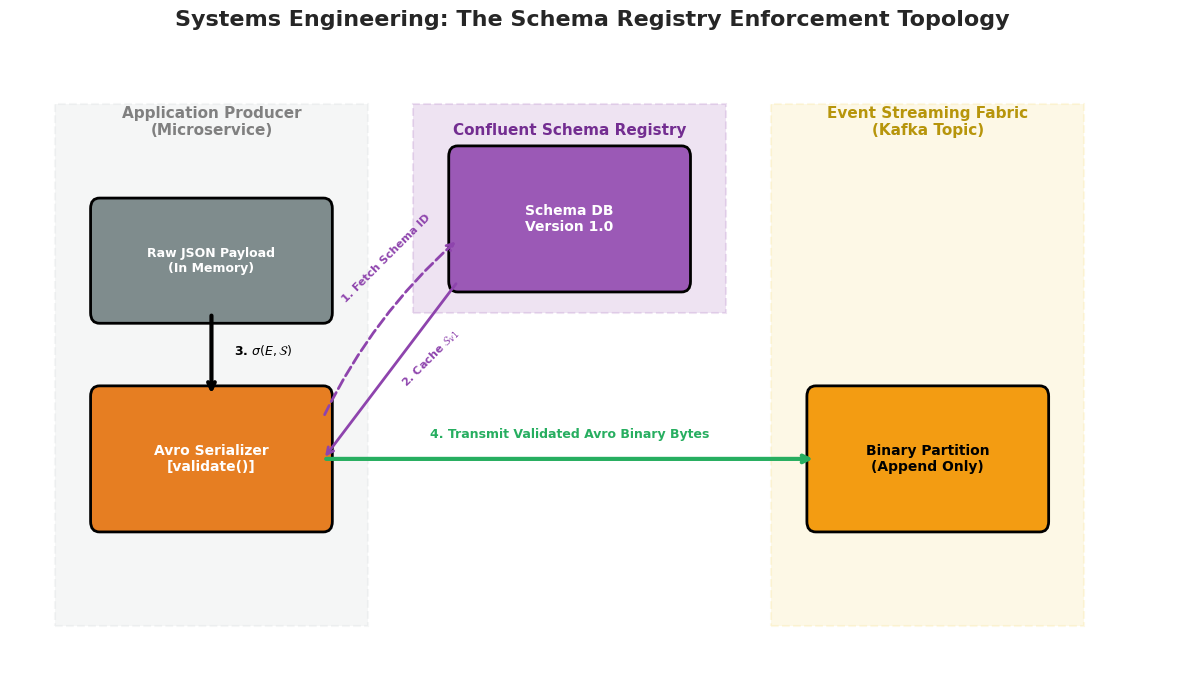

In [3]:
# Visualizing the Schema Registry Handshake Architecture
fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle("Systems Engineering: The Schema Registry Enforcement Topology", fontsize=16, fontweight='bold')

ax.axis('off')

# 1. Define Systems Boundaries
# Producer Zone
prod_box = patches.Rectangle((0.5, 0.5), 3.5, 5.0, fill=True, color='#bdc3c7', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(prod_box)
ax.text(2.25, 5.2, "Application Producer\n(Microservice)", ha='center', color='gray', fontweight='bold', fontsize=11)

# Schema Registry Zone (The Supreme Court)
reg_box = patches.Rectangle((4.5, 3.5), 3.5, 2.0, fill=True, color='#8e44ad', alpha=0.15, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(reg_box)
ax.text(6.25, 5.2, "Confluent Schema Registry", ha='center', color='#732d91', fontweight='bold', fontsize=11)

# Kafka Broker Zone
kafka_box = patches.Rectangle((8.5, 0.5), 3.5, 5.0, fill=True, color='#f1c40f', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--')
ax.add_patch(kafka_box)
ax.text(10.25, 5.2, "Event Streaming Fabric\n(Kafka Topic)", ha='center', color='#b7950b', fontweight='bold', fontsize=11)

# 2. Draw Components
# App Payload
ax.add_patch(patches.FancyBboxPatch((1.0, 3.5), 2.5, 1.0, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#7f8c8d'))
ax.text(2.25, 4.0, "Raw JSON Payload\n(In Memory)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Serializer Engine
ax.add_patch(patches.FancyBboxPatch((1.0, 1.5), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#e67e22'))
ax.text(2.25, 2.1, "Avro Serializer\n[validate()]", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Schema Registry API
ax.add_patch(patches.FancyBboxPatch((5.0, 3.8), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#9b59b6'))
ax.text(6.25, 4.4, "Schema DB\nVersion 1.0", ha='center', va='center', color='white', fontweight='bold', fontsize=10)

# Kafka Partition
ax.add_patch(patches.FancyBboxPatch((9.0, 1.5), 2.5, 1.2, boxstyle="round,pad=0.1", linewidth=2, edgecolor='black', facecolor='#f39c12'))
ax.text(10.25, 2.1, "Binary Partition\n(Append Only)", ha='center', va='center', color='black', fontweight='bold', fontsize=10)

# 3. Draw Directed Edges (The Handshake Physics)

# Step 1: Request Schema
ax.annotate("", xy=(5.0, 4.2), xytext=(3.5, 2.5), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="dashed", connectionstyle="arc3,rad=-0.1"))
ax.text(4.2, 3.6, "1. Fetch Schema ID", ha='center', fontweight='bold', color="#8e44ad", fontsize=8, rotation=45)

# Step 2: Cache Schema Locally
ax.annotate("", xy=(3.5, 2.1), xytext=(5.0, 3.8), arrowprops=dict(arrowstyle="->", lw=2, color="#8e44ad", linestyle="solid"))
ax.text(4.7, 2.8, "2. Cache $\\mathcal{S}_{v1}$", ha='center', fontweight='bold', color="#8e44ad", fontsize=8, rotation=45)

# Step 3: Local Validation
ax.annotate("", xy=(2.25, 2.7), xytext=(2.25, 3.5), arrowprops=dict(arrowstyle="->", lw=3, color="black"))
ax.text(2.5, 3.1, "3. $\\sigma(E, \\mathcal{S})$", ha='left', fontweight='bold', color="black", fontsize=9)

# Step 4: Transmit Safe Binary
ax.annotate("", xy=(9.0, 2.1), xytext=(3.5, 2.1), arrowprops=dict(arrowstyle="->", lw=3, color="#27ae60"))
ax.text(6.25, 2.3, "4. Transmit Validated Avro Binary Bytes", ha='center', fontweight='bold', color="#27ae60", fontsize=9)

plt.xlim(0, 13)
plt.ylim(0, 6)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of the Schema Registry and Data Contracts like **International Customs and Passports**:

* **Schema Drift without Contracts (The Open Border)**: Anyone can walk across the border carrying anything. A software engineer drops a highly explosive payload (a drastically mutated, incompatible JSON schema) onto a truck and drives it across the border into the Data Warehouse. The payload detonates inside the warehouse, destroying the data pipelines and bringing down the company's executive reporting systems for days.
* **Schema Registry (The Passport & Customs Checkpoint)**: You set up a highly secure Customs checkpoint at the exact edge of the software application's memory before data leaves for the network.
* Every single piece of data must possess a valid **Passport (The Schema ID)**.
* The **Customs Officer (The Avro Serializer)** looks up the Passport ID in the centralized global database **(The Schema Registry)**.
* The Officer mathematically measures the cargo against the stated passport rules. *"This passport says you are carrying a strict 32-bit Integer user ID. But you are carrying a String UUID."*
* The Customs Officer physically blocks the truck, sounds an alarm, and rejects the cargo back to the software engineer immediately.



By enforcing Data Contracts, Data Engineers shift the responsibility of data quality from the *downstream consumers* back to the *upstream producers*, guaranteeing a bulletproof Enterprise Data Platform.